# 🧠 Práctica: Implementa tu propio módulo de atención

En esta práctica, implementarás un mecanismo de atención muy simplificado, similar al de los modelos Transformer, utilizando la frase **"El gato duerme"**.

## 🎯 Objetivo
- Calcular los vectores Q, K, V.
- Calcular los scores (atención).
- Aplicar softmax.
- Obtener la representación final para cada palabra.
- Visualizar los resultados.

In [1]:
# Paso 1: Embeddings de entrada (simplificados)
import numpy as np

words = ["El", "gato", "duerme"]
embeddings = {
    "El": np.array([1, 0]),
    "gato": np.array([0, 1]),
    "duerme": np.array([1, 1])
}

In [ ]:
# Paso 2: Definir matrices de pesos Wq, Wk, Wv (simplificadas)
Wq = np.array([[1, 0], [0, 1]])
Wk = np.array([[0, 1], [1, 0]])
Wv = np.array([[1, 1], [0, 1]])

In [ ]:
# Paso 3: Calcular Q, K y V para cada palabra
Q, K, V = {}, {}, {}
for word, vec in embeddings.items():
    Q[word] = vec @ Wq
    K[word] = vec @ Wk
    V[word] = vec @ Wv

Q, K, V

In [ ]:
# Paso 4: Calcular scores (producto escalar de Q y K)
score_matrix = np.zeros((3, 3))
for i, q_word in enumerate(words):
    for j, k_word in enumerate(words):
        score_matrix[i, j] = np.dot(Q[q_word], K[k_word])

score_matrix

In [ ]:
# Paso 5: Aplicar softmax para obtener los pesos de atención
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

attention_weights = np.apply_along_axis(softmax, 1, score_matrix)
attention_weights

In [ ]:
# Paso 6: Calcular las salidas ponderadas usando los valores (V)
outputs = []
for i in range(len(words)):
    weighted_sum = sum(attention_weights[i, j] * V[words[j]] for j in range(len(words)))
    outputs.append(weighted_sum)

outputs

## 🔄 Atención Multi-Cabeza

Hasta ahora hemos trabajado con una sola "cabeza de atención". En los modelos Transformer reales se usan **múltiples cabezas de atención al mismo tiempo**.

### 🧠 ¿Por qué usar múltiples cabezas?
- Cada cabeza puede enfocarse en diferentes tipos de relaciones entre palabras.
- Algunas cabezas podrían prestar atención a la estructura gramatical, otras al significado semántico.
- Permite al modelo **capturar distintos aspectos del contexto** de forma más rica y completa.

### 🧪 ¿Cómo funciona?
1. Se calculan múltiples matrices Q, K y V usando diferentes pesos.
2. Cada cabeza realiza su propio mecanismo de atención.
3. Los resultados de todas las cabezas se **combinan (concatenan)**.
4. Se aplica una capa final que mezcla esa información.

Esto mejora significativamente la capacidad del modelo para entender relaciones complejas en el texto.

In [ ]:
# Paso 7: Visualización de la matriz de atención
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(attention_weights, index=words, columns=words)
plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Matriz de Atención")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

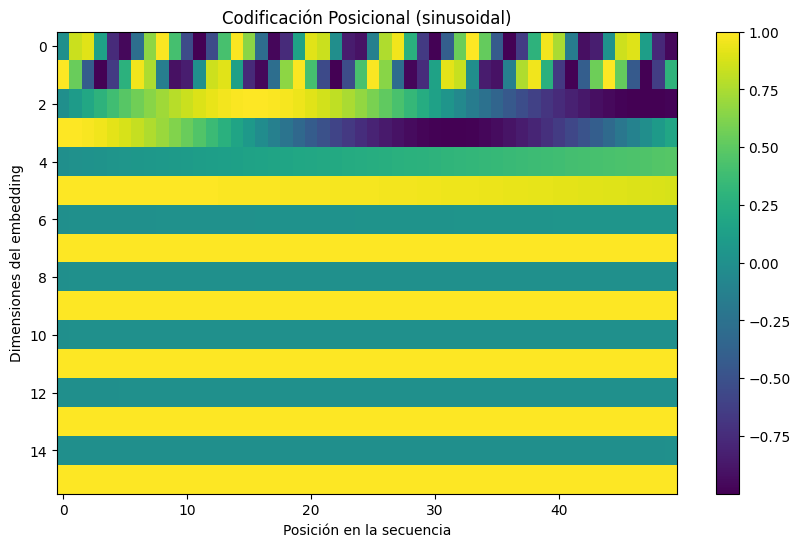

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(pos, d_model):
    PE = np.zeros((pos, d_model))
    for p in range(pos):
        for i in range(0, d_model, 2):
            angle = p / (10000 ** ((2 * i)/d_model))
            PE[p, i] = np.sin(angle)
            if i+1 < d_model:
                PE[p, i+1] = np.cos(angle)
    return PE

# Generamos PE para las primeras 50 posiciones
pe = positional_encoding(50, 16)

plt.figure(figsize=(10, 6))
plt.imshow(pe.T, cmap='viridis', aspect='auto')
plt.xlabel("Posición en la secuencia")
plt.ylabel("Dimensiones del embedding")
plt.title("Codificación Posicional (sinusoidal)")
plt.colorbar()
plt.show()

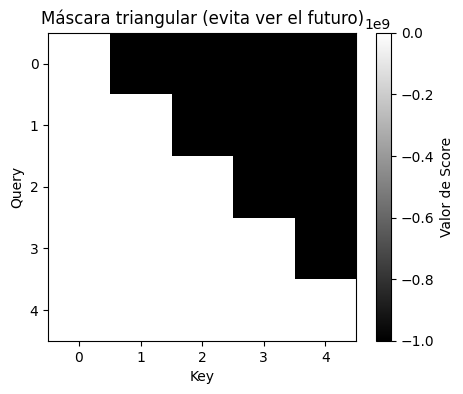

In [2]:
import numpy as np
import matplotlib.pyplot as plt

seq_len = 5
mask = np.triu(np.ones((seq_len, seq_len)), k=1) * -1e9

plt.figure(figsize=(5, 4))
plt.imshow(mask, cmap="gray")
plt.title("Máscara triangular (evita ver el futuro)")
plt.xlabel("Key")
plt.ylabel("Query")
plt.colorbar(label="Valor de Score")
plt.show()